In [20]:
from langchain_groq import ChatGroq
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display

In [ ]:
groq_api_key='paste your groq api key here'
llm=ChatGroq(groq_api_key=groq_api_key, model_name='Gemma2-9b-It')

In [22]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    sentiment: str

#Preprocessing Node
def preprocess(state: State)->State:
    cleaned=state['messages'][-1].content.strip()
    state['messages'][-1].content=cleaned
    return state

#Sentiment Analysis Node
def sentiment_analysis(state: State)->State:
    msg=state['messages'][-1].content
    state['sentiment']='positive' if 'good' in msg else 'neutral'
    return state

#Chatbot Node
def chatbot(state: State)->State:
    return{'messages': llm.invoke(state['messages'])}

#Logging Node
def logger(state: State)->State:
    print(f"LOG: {state['messages'][-1].content}, Sentiment: {state.get('sentiment')}")
    return state

In [23]:
#Buld the graph
builder=StateGraph(State)
builder.add_node('preprocess', preprocess)
builder.add_node('sentiment_analysis', sentiment_analysis)
builder.add_node('chatbot', chatbot)
builder.add_node('logger', logger)

In [24]:
#Define the flow
builder.add_edge(START, 'preprocess')
builder.add_edge('preprocess', 'sentiment_analysis')    
builder.add_edge('sentiment_analysis', 'chatbot')
builder.add_edge('chatbot', 'logger')
builder.add_edge('logger', END)

In [25]:
graph=builder.compile()

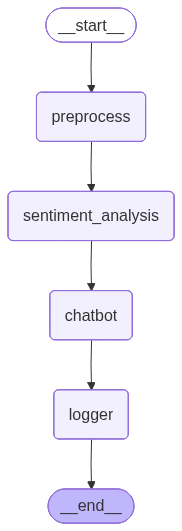

In [26]:
#Drawing the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [27]:
#Invoke the graph
input_message="Hello, this is a test message!"
final_state=graph.invoke({'messages':('user', input_message)})

#Print the final response
print('Final State:', final_state)
print('Chatbot Response:', final_state['messages'][-1].content)
print('Sentiment:', final_state.get('sentiment'))

input_message2='This is a neutral message'
final_state2=graph.invoke({'messages':('user', input_message2)})
print('Final State:', final_state2)
print('Chatbot Response:', final_state2['messages'][-1].content)
print('Sentiment:', final_state2.get('sentiment'))

LOG: Hello! Your test message was received loud and clear.  

Is there anything else I can help you with?
, Sentiment: neutral
Final State: {'messages': [HumanMessage(content='Hello, this is a test message!', additional_kwargs={}, response_metadata={}, id='ae0178b2-23e2-4fb9-bf52-aa03eeb6340a'), AIMessage(content='Hello! Your test message was received loud and clear.  \n\nIs there anything else I can help you with?\n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 17, 'total_tokens': 43, 'completion_time': 0.047272727, 'prompt_time': 0.001263309, 'queue_time': 0.25202829, 'total_time': 0.048536036}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--97f323b9-0f96-4398-b239-31d3804d8bae-0', usage_metadata={'input_tokens': 17, 'output_tokens': 26, 'total_tokens': 43})], 'sentiment': 'neutral'}
Chatbot Response: Hello! Your test message w